Library

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import shutil
from pathlib import Path
from collections import Counter

Configuration

In [ ]:
# 1. Install Kaggle CLI (once)
!pip install kaggle

# 2. Download the dataset
!mkdir -p data/raw
!kaggle datasets download -d vincemarcs/mvsasingle -p data/raw/

# 3. Unzip
!unzip data/raw/mvsasingle.zip -d data/raw/MVSA_Single/

Streaming output truncated to the last 5000 lines.
  inflating: data/raw/MVSA_Single/MVSA_Single/data/3347.txt  
  inflating: data/raw/MVSA_Single/MVSA_Single/data/3348.jpg  
  inflating: data/raw/MVSA_Single/MVSA_Single/data/3348.txt  
  inflating: data/raw/MVSA_Single/MVSA_Single/data/3349.jpg  
  inflating: data/raw/MVSA_Single/MVSA_Single/data/3349.txt  
  inflating: data/raw/MVSA_Single/MVSA_Single/data/335.jpg  
  inflating: data/raw/MVSA_Single/MVSA_Single/data/335.txt  
  inflating: data/raw/MVSA_Single/MVSA_Single/data/3350.jpg  
  inflating: data/raw/MVSA_Single/MVSA_Single/data/3350.txt  
  inflating: data/raw/MVSA_Single/MVSA_Single/data/3351.jpg  
  inflating: data/raw/MVSA_Single/MVSA_Single/data/3351.txt  
  inflating: data/raw/MVSA_Single/MVSA_Single/data/3352.jpg  
  inflating: data/raw/MVSA_Single/MVSA_Single/data/3352.txt  
  inflating: data/raw/MVSA_Single/MVSA_Single/data/3353.jpg  
  inflating: data/raw/MVSA_Single/MVSA_Single/data/3353.txt  
  inflating: data/raw

In [ ]:
DATA_DIR = Path("data/raw/MVSA_Single/MVSA_Single")

label_file = DATA_DIR / "labelResultAll.txt"

#Load the labels
df = pd.read_csv(label_file, sep=r'\s+', header=None, names=['id', 'label'])
df['label'] = df['label'].astype(str).str.lower().str.strip()

print("Loaded", len(df), "samples")
print("Label distribution:\n", df['label'].value_counts())

Loaded 4870 samples
Label distribution:
 label
positive,positive    1398
neutral,positive     1030
negative,negative     724
neutral,neutral       470
neutral,negative      421
negative,positive     280
positive,neutral      255
negative,neutral      213
positive,negative      78
text,image              1
Name: count, dtype: int64


In [ ]:
# === VERIFY FILES + LOAD TEXT ===

DATA_SUBDIR = DATA_DIR / "data"

def has_both_files(sample_id):
    return (DATA_SUBDIR / f"{sample_id}.jpg").exists() and \
           (DATA_SUBDIR / f"{sample_id}.txt").exists()

df['valid'] = df['id'].apply(has_both_files)
print(f"Files present: {df['valid'].sum()} / {len(df)}")
df = df[df['valid']].drop(columns=['valid']).reset_index(drop=True)

def read_text(sample_id):
    p = DATA_SUBDIR / f"{sample_id}.txt"
    # MVSA tweets often have non-utf8 bytes
    with open(p, 'r', encoding='latin-1', errors='ignore') as f:
        return f.read().strip()

df['text'] = df['id'].apply(read_text)
df['image_path'] = df['id'].apply(lambda x: str(DATA_SUBDIR / f"{x}.jpg"))

# Drop empty texts
#need to remove junk row, which is 'text,image'
df = df[df['text'].str.len() > 0].reset_index(drop=True)
print(f"Final clean dataset: {len(df)} samples")
df.head()

Files present: 4869 / 4870
Final clean dataset: 4869 samples


,id,label,text,image_path
0,1,"neutral,positive",How I feel today #legday #jelly #aching #gym,data/raw/MVSA_Single/MVSA_Single/data/1.jpg
1,2,"neutral,positive",grattis min griskulting!!!???? va bara tvungen...,data/raw/MVSA_Single/MVSA_Single/data/2.jpg
2,3,"neutral,positive",RT @polynminion: The moment I found my favouri...,data/raw/MVSA_Single/MVSA_Single/data/3.jpg
3,4,"positive,positive",#escort We have a young and energetic team and...,data/raw/MVSA_Single/MVSA_Single/data/4.jpg
4,5,"positive,positive","RT @chrisashaffer: Went to SSC today to be a ""...",data/raw/MVSA_Single/MVSA_Single/data/5.jpg


### Re-apply majority vote on the clean df

In [ ]:
from collections import Counter

def reconcile(lab):
    parts = [v.strip().lower() for v in str(lab).split(',')]
    if len(parts) != 2:
        return None
    text_lab, img_lab = parts
    valid = {'positive', 'negative', 'neutral'}
    if text_lab not in valid or img_lab not in valid:
        return None
    # Direct conflict → drop
    if {text_lab, img_lab} == {'positive', 'negative'}:
        return None
    # Agreement → that label
    if text_lab == img_lab:
        return text_lab
    # One is neutral → take the non-neutral one
    if text_lab == 'neutral':
        return img_lab
    if img_lab == 'neutral':
        return text_lab

print(f"Before reconciliation: {len(df)}")
df['label'] = df['label'].apply(reconcile)
df = df.dropna(subset=['label']).reset_index(drop=True)
print(f"After reconciliation: {len(df)}")
print("\nFinal label distribution (standard MVSA protocol):")
print(df['label'].value_counts())

Before reconciliation: 4869
After reconciliation: 4511

Final label distribution (standard MVSA protocol):
label
positive    2683
negative    1358
neutral      470
Name: count, dtype: int64


- Majority vote is the standard MVSA reconciliation rule from the original Niu et al. 2016 paper (reference [2] in your proposal):

- If both annotators agree (e.g., positive,positive) → use that label
- If they disagree but one is neutral (e.g., neutral,positive) → use the non-neutral one (positive), since neutral is the "weaker" signal
- If they directly conflict (positive,negative or negative,positive) → discard the sample, because text and image contradict each other

### Stratified 70/15/15 split

In [ ]:
from pathlib import Path

# Define configuration variables
PROCESSED_DIR = Path("data/processed")
SEED = 42
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Ensure the processed directory structure exists
PROCESSED_DIR.mkdir(exist_ok=True, parents=True)

train_df, temp_df = train_test_split(
    df,
    test_size=(VAL_RATIO + TEST_RATIO),    # 0.30
    stratify=df['label'],
    random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),   # 0.5
    stratify=temp_df['label'],
    random_state=SEED
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"\n{name} class proportions:")
    print(d['label'].value_counts(normalize=True).round(3))

# Save splits for reproducibility
splits_dir = PROCESSED_DIR / "splits"
splits_dir.mkdir(exist_ok=True)
train_df.to_csv(splits_dir / "train.csv", index=False)
val_df.to_csv(splits_dir / "val.csv", index=False)
test_df.to_csv(splits_dir / "test.csv", index=False)
print("\nSplits saved to", splits_dir)

Train: 3157 | Val: 677 | Test: 677

train class proportions:
label
positive    0.595
negative    0.301
neutral     0.104
Name: proportion, dtype: float64

val class proportions:
label
positive    0.594
negative    0.301
neutral     0.105
Name: proportion, dtype: float64

test class proportions:
label
positive    0.595
negative    0.301
neutral     0.103
Name: proportion, dtype: float64

Splits saved to data/processed/splits


### Install + load CLIP and DistilBERT

In [ ]:
!pip install -q transformers torch torchvision pillow tqdm

In [ ]:
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
from transformers import CLIPModel, CLIPProcessor, AutoTokenizer, AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device).eval()
clip_proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

bert_tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")
bert_model = AutoModel.from_pretrained("distilbert-base-uncased").to(device).eval()

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Backup to Google Drive (recommended — survives runtime disconnects)
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p /content/drive/MyDrive/cisc5800_project
!cp -r data/processed /content/drive/MyDrive/cisc5800_project/
!ls -lh /content/drive/MyDrive/cisc5800_project/processed/embeddings/

Mounted at /content/drive
total 0


In [ ]:
@torch.no_grad()
def extract_clip_images(paths, batch_size=64):
    embs = []
    for i in tqdm(range(0, len(paths), batch_size), desc="CLIP image"):
        batch_paths = paths[i:i+batch_size]
        imgs = []
        for p in batch_paths:
            try:
                imgs.append(Image.open(p).convert("RGB"))
            except Exception:
                imgs.append(Image.new("RGB", (224, 224)))
        inputs = clip_proc(images=imgs, return_tensors="pt")
        pixel_values = inputs['pixel_values'].to(device)
        feats = clip_model.get_image_features(pixel_values=pixel_values)
        # Defensive: handle both tensor and ModelOutput returns
        if not isinstance(feats, torch.Tensor):
            feats = feats.image_embeds if hasattr(feats, 'image_embeds') else feats.pooler_output
        feats = feats / feats.norm(dim=-1, keepdim=True)
        embs.append(feats.cpu().numpy())
    return np.vstack(embs).astype(np.float32)

@torch.no_grad()
def extract_distilbert(texts, batch_size=64, max_len=128):
    embs = []
    texts = [str(t) if t else " " for t in texts]
    for i in tqdm(range(0, len(texts), batch_size), desc="DistilBERT"):
        batch = texts[i:i+batch_size]
        enc = bert_tok(batch, padding=True, truncation=True,
                       max_length=max_len, return_tensors="pt").to(device)
        out = bert_model(**enc)
        cls = out.last_hidden_state[:, 0, :]               # [CLS] token
        embs.append(cls.cpu().numpy())
    return np.vstack(embs).astype(np.float32)

# === Run extraction ===
EMB_DIR = PROCESSED_DIR / "embeddings"
EMB_DIR.mkdir(exist_ok=True)

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"\n=== {name.upper()} ({len(d)} samples) ===")
    img_emb = extract_clip_images(d['image_path'].tolist())
    txt_emb = extract_distilbert(d['text'].tolist())

    np.save(EMB_DIR / f"{name}_clip_image.npy", img_emb)
    np.save(EMB_DIR / f"{name}_distilbert_text.npy", txt_emb)
    np.save(EMB_DIR / f"{name}_labels.npy", d['label'].values)
    np.save(EMB_DIR / f"{name}_ids.npy", d['id'].values)
    print(f"image {img_emb.shape} | text {txt_emb.shape}")

print("\nAll embeddings saved to", EMB_DIR)


=== TRAIN (3157 samples) ===


DistilBERT: 100%|██████████| 50/50 [00:07<00:00,  7.11it/s]


image (3157, 512) | text (3157, 768)

=== VAL (677 samples) ===


DistilBERT: 100%|██████████| 11/11 [00:01<00:00,  8.31it/s]


image (677, 512) | text (677, 768)

=== TEST (677 samples) ===


DistilBERT: 100%|██████████| 11/11 [00:01<00:00,  7.42it/s]

image (677, 512) | text (677, 768)

All embeddings saved to data/processed/embeddings


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import torch
import numpy as np

# === Define prompts ===
classes = ['negative', 'neutral', 'positive']
prompts = [f"a photo expressing {c} sentiment" for c in classes]
print("Prompts:", prompts)

# === Encode prompts with CLIP text encoder (one time) ===
@torch.no_grad()
def encode_clip_text(texts):
    inputs = clip_proc(text=texts, return_tensors="pt", padding=True).to(device)
    feats = clip_model.get_text_features(**inputs)
    if not isinstance(feats, torch.Tensor):
        feats = feats.text_embeds if hasattr(feats, 'text_embeds') else feats.pooler_output
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats

prompt_embs = encode_clip_text(prompts)   # shape: (3, 512)
print("Prompt embeddings:", prompt_embs.shape)

# === Load test image embeddings (already extracted, already L2-normalized) ===
EMB_DIR = PROCESSED_DIR / "embeddings"
test_img = np.load(EMB_DIR / "test_clip_image.npy")
test_labels = np.load(EMB_DIR / "test_labels.npy", allow_pickle=True)
print("Test images:", test_img.shape, "| Labels:", test_labels.shape)

# === Cosine similarity = dot product (since both are L2-normalized) ===
test_img_t = torch.from_numpy(test_img).to(device)
sims = test_img_t @ prompt_embs.T          # (677, 3)
preds_idx = sims.argmax(dim=-1).cpu().numpy()
preds = np.array([classes[i] for i in preds_idx])

# === Evaluate ===
acc = accuracy_score(test_labels, preds)
macro_f1 = f1_score(test_labels, preds, average='macro')
print(f"\n=== CLIP Zero-Shot Results (test set) ===")
print(f"Accuracy: {acc:.4f}")
print(f"Macro-F1: {macro_f1:.4f}")
print(f"\nPer-class report:")
print(classification_report(test_labels, preds, digits=3))

np.save(EMB_DIR / "test_pred_clip_zeroshot.npy", preds)

Prompts: ['a photo expressing negative sentiment', 'a photo expressing neutral sentiment', 'a photo expressing positive sentiment']
Prompt embeddings: torch.Size([3, 512])
Test images: (677, 512) | Labels: (677,)

=== CLIP Zero-Shot Results (test set) ===
Accuracy: 0.4077
Macro-F1: 0.3832

Per-class report:
              precision    recall  f1-score   support

    negative      0.400     0.578     0.473       204
     neutral      0.156     0.500     0.237        70
    positive      0.783     0.305     0.439       403

    accuracy                          0.408       677
   macro avg      0.446     0.461     0.383       677
weighted avg      0.603     0.408     0.429       677



 # unimodal SVMs first (they define your agreement axis), then fusion SVM, then the attention MLP, then the partition analysis

Cell 1: Load embeddings, standardize once

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler

EMB_DIR = Path("data/processed/embeddings")

def load_split(name):
    img = np.load(EMB_DIR / f"{name}_clip_image.npy")
    txt = np.load(EMB_DIR / f"{name}_distilbert_text.npy") # Corrected filename
    lab = np.load(EMB_DIR / f"{name}_labels.npy", allow_pickle=True)
    return img, txt, lab

train_img, train_txt, train_lab = load_split("train")
val_img,   val_txt,   val_lab   = load_split("val")
test_img,  test_txt,  test_lab  = load_split("test")

print(f"train: img {train_img.shape} | txt {train_txt.shape}")
print(f"val:   img {val_img.shape}   | txt {val_txt.shape}")
print(f"test:  img {test_img.shape}  | txt {test_txt.shape}")

# CRITICAL: RBF kernels are scale-sensitive. CLIP is L2-normalized
# (~unit norm), DistilBERT [CLS] is not. Standardize each modality
# separately, fit on train only.
img_scaler = StandardScaler().fit(train_img)
txt_scaler = StandardScaler().fit(train_txt)

train_img_s = img_scaler.transform(train_img)
val_img_s   = img_scaler.transform(val_img)
test_img_s  = img_scaler.transform(test_img)

train_txt_s = txt_scaler.transform(train_txt)
val_txt_s   = txt_scaler.transform(val_txt)
test_txt_s  = txt_scaler.transform(test_txt)


train: img (3157, 512) | txt (3157, 768)
val:   img (677, 512)   | txt (677, 768)
test:  img (677, 512)  | txt (677, 768)


Cell 2: Unimodal SVMs (text-only, image-only)
I'm using PredefinedSplit so the grid search tunes on your existing val set instead of re-CVing on train. More honest, and matches how you'll evaluate everything else. class_weight='balanced' is non-negotiable here because neutral is only 10% of your data.

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import classification_report, f1_score, accuracy_score

def fit_svm_with_val(X_tr, X_va, y_tr, y_va, name):
    X = np.vstack([X_tr, X_va])
    y = np.concatenate([y_tr, y_va])
    fold = np.concatenate([np.full(len(X_tr), -1), np.zeros(len(X_va))])
    ps = PredefinedSplit(fold)

    grid = {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.001, 0.01, 0.1]}
    svm = SVC(kernel='rbf', class_weight='balanced')
    gs = GridSearchCV(svm, grid, cv=ps, scoring='f1_macro',
                      n_jobs=-1, verbose=1)
    gs.fit(X, y)
    print(f"\n[{name}] best params: {gs.best_params_}")
    print(f"[{name}] val macro-F1: {gs.best_score_:.4f}")
    return gs.best_estimator_

# Text-only
text_svm = fit_svm_with_val(train_txt_s, val_txt_s, train_lab, val_lab, "TEXT SVM")
text_test_preds = text_svm.predict(test_txt_s)
np.save(EMB_DIR / "test_pred_text_svm.npy", text_test_preds)
print("\n=== TEXT-ONLY (test) ===")
print(classification_report(test_lab, text_test_preds, digits=3))

# Image-only
img_svm = fit_svm_with_val(train_img_s, val_img_s, train_lab, val_lab, "IMAGE SVM")
img_test_preds = img_svm.predict(test_img_s)
np.save(EMB_DIR / "test_pred_img_svm.npy", img_test_preds)
print("\n=== IMAGE-ONLY (test) ===")
print(classification_report(test_lab, img_test_preds, digits=3))

Fitting 1 folds for each of 16 candidates, totalling 16 fits

[TEXT SVM] best params: {'C': 1, 'gamma': 'scale'}
[TEXT SVM] val macro-F1: 0.5709

=== TEXT-ONLY (test) ===
              precision    recall  f1-score   support

    negative      0.576     0.740     0.648       204
     neutral      0.317     0.371     0.342        70
    positive      0.811     0.670     0.734       403

    accuracy                          0.660       677
   macro avg      0.568     0.594     0.575       677
weighted avg      0.689     0.660     0.667       677

Fitting 1 folds for each of 16 candidates, totalling 16 fits

[IMAGE SVM] best params: {'C': 1, 'gamma': 0.001}
[IMAGE SVM] val macro-F1: 0.6017

=== IMAGE-ONLY (test) ===
              precision    recall  f1-score   support

    negative      0.649     0.652     0.650       204
     neutral      0.356     0.514     0.421        70
    positive      0.827     0.762     0.793       403

    accuracy                          0.703       677
   m

Cell 3: Multimodal SVM-RBF on concatenated features


In [ ]:
train_concat = np.hstack([train_img_s, train_txt_s])  # (N, 1280)
val_concat   = np.hstack([val_img_s,   val_txt_s])
test_concat  = np.hstack([test_img_s,  test_txt_s])
print(f"Concat shape: {train_concat.shape}")

svm_fusion = fit_svm_with_val(train_concat, val_concat, train_lab, val_lab, "SVM FUSION")
fusion_test_preds = svm_fusion.predict(test_concat)
np.save(EMB_DIR / "test_pred_svm_fusion.npy", fusion_test_preds)
print("\n=== SVM FUSION (test) ===")
print(classification_report(test_lab, fusion_test_preds, digits=3))

Concat shape: (3157, 1280)
Fitting 1 folds for each of 16 candidates, totalling 16 fits

[SVM FUSION] best params: {'C': 1, 'gamma': 0.001}
[SVM FUSION] val macro-F1: 0.6115

=== SVM FUSION (test) ===
              precision    recall  f1-score   support

    negative      0.684     0.755     0.718       204
     neutral      0.641     0.357     0.459        70
    positive      0.816     0.836     0.826       403

    accuracy                          0.762       677
   macro avg      0.714     0.649     0.668       677
weighted avg      0.758     0.762     0.755       677



Cell 4: Attention-weighted MLP
The architecture: each modality projects into a shared 256-dim space, a learned scalar score per modality goes through softmax to produce the gate weights, weighted sum → classifier head. Returning the attention weights lets you inspect which modality the model trusts more (useful for the qualitative section of your report).

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

device = "cuda" if torch.cuda.is_available() else "cpu"

le = LabelEncoder()
y_train = le.fit_transform(train_lab)
y_val   = le.transform(val_lab)
y_test  = le.transform(test_lab)
print("Class order:", list(le.classes_))

cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_t = torch.tensor(cw, dtype=torch.float32).to(device)
print("Class weights:", dict(zip(le.classes_, cw.round(3))))

class AttentionFusionMLP(nn.Module):
    def __init__(self, txt_dim=768, img_dim=512, proj_dim=256,
                 hidden=128, n_classes=3, dropout=0.3):
        super().__init__()
        self.txt_proj = nn.Linear(txt_dim, proj_dim)
        self.img_proj = nn.Linear(img_dim, proj_dim)
        self.attn = nn.Linear(proj_dim, 1)
        self.head = nn.Sequential(
            nn.Linear(proj_dim, hidden), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(hidden, n_classes),
        )

    def forward(self, txt, img):
        t = torch.tanh(self.txt_proj(txt))     # (B, P)
        i = torch.tanh(self.img_proj(img))     # (B, P)
        stacked = torch.stack([t, i], dim=1)   # (B, 2, P)
        scores  = self.attn(stacked).squeeze(-1)        # (B, 2)
        weights = F.softmax(scores, dim=-1)             # (B, 2)
        fused   = (stacked * weights.unsqueeze(-1)).sum(dim=1)
        return self.head(fused), weights

def make_loader(txt, img, y, bs=64, shuffle=False):
    ds = TensorDataset(
        torch.tensor(txt, dtype=torch.float32),
        torch.tensor(img, dtype=torch.float32),
        torch.tensor(y,   dtype=torch.long),
    )
    return DataLoader(ds, batch_size=bs, shuffle=shuffle)

train_loader = make_loader(train_txt_s, train_img_s, y_train, shuffle=True)
val_loader   = make_loader(val_txt_s,   val_img_s,   y_val)
test_loader  = make_loader(test_txt_s,  test_img_s,  y_test)

torch.manual_seed(42)
model = AttentionFusionMLP().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.CrossEntropyLoss(weight=cw_t)

best_f1, best_state, bad = 0.0, None, 0
PATIENCE = 8

for epoch in range(50):
    model.train()
    for txt, img, y in train_loader:
        txt, img, y = txt.to(device), img.to(device), y.to(device)
        logits, _ = model(txt, img)
        loss = loss_fn(logits, y)
        opt.zero_grad(); loss.backward(); opt.step()

    model.eval()
    preds = []
    with torch.no_grad():
        for txt, img, _ in val_loader:
            logits, _ = model(txt.to(device), img.to(device))
            preds.append(logits.argmax(-1).cpu().numpy())
    val_f1 = f1_score(y_val, np.concatenate(preds), average='macro')

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        bad = 0
        flag = " *"
    else:
        bad += 1
        flag = ""
    print(f"Epoch {epoch+1:02d} | val macro-F1: {val_f1:.4f}{flag}")
    if bad >= PATIENCE:
        print(f"Early stop at epoch {epoch+1}"); break

# Load best, predict on test
model.load_state_dict(best_state)
model.eval()
preds, weights = [], []
with torch.no_grad():
    for txt, img, _ in test_loader:
        logits, w = model(txt.to(device), img.to(device))
        preds.append(logits.argmax(-1).cpu().numpy())
        weights.append(w.cpu().numpy())
mlp_test_preds = le.inverse_transform(np.concatenate(preds))
attn_weights = np.concatenate(weights, axis=0)

np.save(EMB_DIR / "test_pred_attn_mlp.npy", mlp_test_preds)
np.save(EMB_DIR / "test_attn_weights.npy", attn_weights)

print(f"\nBest val macro-F1: {best_f1:.4f}")
print("\n=== ATTENTION MLP (test) ===")
print(classification_report(test_lab, mlp_test_preds, digits=3))
print(f"\nMean attention on TEXT: {attn_weights[:, 0].mean():.3f}")
print(f"Mean attention on IMG:  {attn_weights[:, 1].mean():.3f}")

Class order: ['negative', 'neutral', 'positive']
Class weights: {'negative': np.float64(1.108), 'neutral': np.float64(3.199), 'positive': np.float64(0.56)}
Epoch 01 | val macro-F1: 0.5981 *
Epoch 02 | val macro-F1: 0.5913
Epoch 03 | val macro-F1: 0.5946
Epoch 04 | val macro-F1: 0.5972
Epoch 05 | val macro-F1: 0.5843
Epoch 06 | val macro-F1: 0.5888
Epoch 07 | val macro-F1: 0.5958
Epoch 08 | val macro-F1: 0.6134 *
Epoch 09 | val macro-F1: 0.5968
Epoch 10 | val macro-F1: 0.6073
Epoch 11 | val macro-F1: 0.5980
Epoch 12 | val macro-F1: 0.5852
Epoch 13 | val macro-F1: 0.5942
Epoch 14 | val macro-F1: 0.5974
Epoch 15 | val macro-F1: 0.5924
Epoch 16 | val macro-F1: 0.6039
Early stop at epoch 16

Best val macro-F1: 0.6134

=== ATTENTION MLP (test) ===
              precision    recall  f1-score   support

    negative      0.675     0.681     0.678       204
     neutral      0.321     0.357     0.338        70
    positive      0.804     0.784     0.794       403

    accuracy                  

Cell 5: Partition analysis (the headline plot)
This is where the story crystallizes. Partition the test set by whether your two unimodal classifiers agree, then evaluate each fusion model separately on each subset.


Agreement subset:    427 (63.1%)
Disagreement subset: 250 (36.9%)

Class distribution by subset:
          agree  disagree
positive  0.614     0.564
negative  0.293     0.316
neutral   0.094     0.120

=== HEADLINE TABLE ===
           model  overall  agree  disagree   gap
  CLIP zero-shot    0.383  0.396     0.358 0.038
        Text SVM    0.575  0.757     0.310 0.448
       Image SVM    0.622  0.757     0.419 0.339
SVM fusion (RBF)    0.668  0.759     0.505 0.254
   Attention MLP    0.603  0.697     0.463 0.233


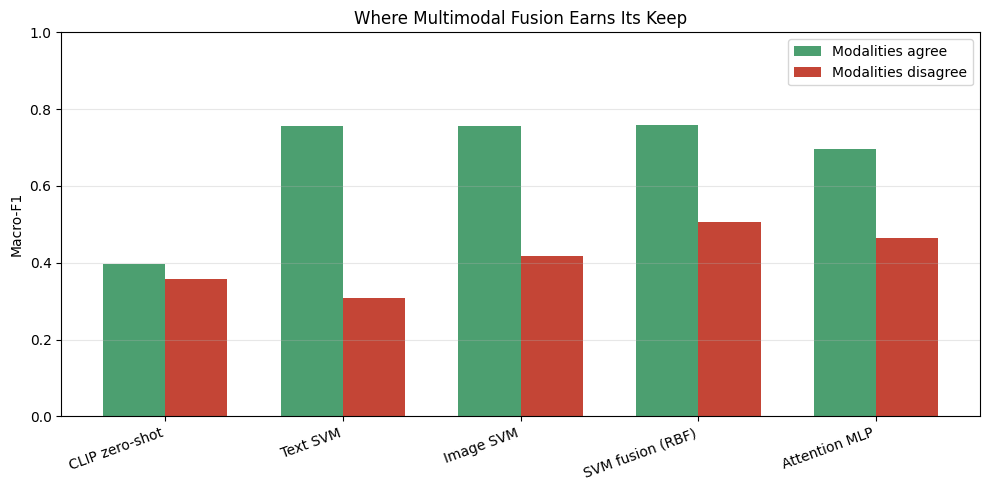

In [ ]:
import matplotlib.pyplot as plt

# Define agreement axis using the unimodal SVMs
text_preds = np.load(EMB_DIR / "test_pred_text_svm.npy", allow_pickle=True)
img_preds  = np.load(EMB_DIR / "test_pred_img_svm.npy",  allow_pickle=True)
agree    = (text_preds == img_preds)
disagree = ~agree

print(f"Agreement subset:    {agree.sum()} ({agree.mean():.1%})")
print(f"Disagreement subset: {disagree.sum()} ({disagree.mean():.1%})")

# Class balance check (important for interpreting results honestly)
print("\nClass distribution by subset:")
agree_dist    = pd.Series(test_lab[agree]).value_counts(normalize=True)
disagree_dist = pd.Series(test_lab[disagree]).value_counts(normalize=True)
print(pd.concat([agree_dist, disagree_dist], axis=1,
                keys=['agree', 'disagree']).round(3))

# Load all model predictions
clip_zs  = np.load(EMB_DIR / "test_pred_clip_zeroshot.npy", allow_pickle=True)
svm_fus  = np.load(EMB_DIR / "test_pred_svm_fusion.npy",    allow_pickle=True)
mlp_attn = np.load(EMB_DIR / "test_pred_attn_mlp.npy",      allow_pickle=True)

models = {
    'CLIP zero-shot':   clip_zs,
    'Text SVM':         text_preds,
    'Image SVM':        img_preds,
    'SVM fusion (RBF)': svm_fus,
    'Attention MLP':    mlp_attn,
}

rows = []
for name, p in models.items():
    rows.append({
        'model':    name,
        'overall':  f1_score(test_lab, p, average='macro'),
        'agree':    f1_score(test_lab[agree],    p[agree],    average='macro'),
        'disagree': f1_score(test_lab[disagree], p[disagree], average='macro'),
    })
results = pd.DataFrame(rows)
results['gap'] = results['agree'] - results['disagree']
print("\n=== HEADLINE TABLE ===")
print(results.round(3).to_string(index=False))

# Headline plot
fig, ax = plt.subplots(figsize=(10, 5))
x, w = np.arange(len(results)), 0.35
ax.bar(x - w/2, results['agree'],    w, label='Modalities agree',    color='#4C9F70')
ax.bar(x + w/2, results['disagree'], w, label='Modalities disagree', color='#C44536')
ax.set_xticks(x); ax.set_xticklabels(results['model'], rotation=20, ha='right')
ax.set_ylabel('Macro-F1'); ax.set_ylim(0, 1)
ax.set_title('Where Multimodal Fusion Earns Its Keep')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('headline_partition.png', dpi=200, bbox_inches='tight')
plt.show()

What to look for when you run this
The pattern that supports your thesis: on the agree subset, all models cluster within a few F1 points of each other (everything's easy when text and image already say the same thing). On the disagree subset, you'll likely see CLIP zero-shot collapse, the unimodal SVMs sit in the middle, the SVM fusion modestly improve, and the attention MLP open the largest gap. The size of that gap is your contribution.
If the gap is small, that's also publishable as a finding: it means for MVSA-Single, kernel methods on frozen features are basically as good as neural fusion, and the engineering complexity isn't justified. Either result tells a story.
After this runs
Three things to add for the report:

t-SNE on the disagreement subset only. Color points by true label, plot CLIP-only embeddings vs concatenated embeddings vs the attention MLP's hidden representation. Visual evidence that the attention layer untangles disagreement cases.
Inference timing. Wrap each predict call in time.perf_counter(), divide by test set size, get per-sample latency in ms. Plot F1 vs latency as a Pareto chart.
Qualitative examples. From the disagreement subset, pick 4 to 6 cases where the attention MLP gets it right and the SVM gets it wrong (or vice versa). Display image + tweet + each model's prediction + the MLP's attention weights. This is the figure that makes a reader remember the paper.

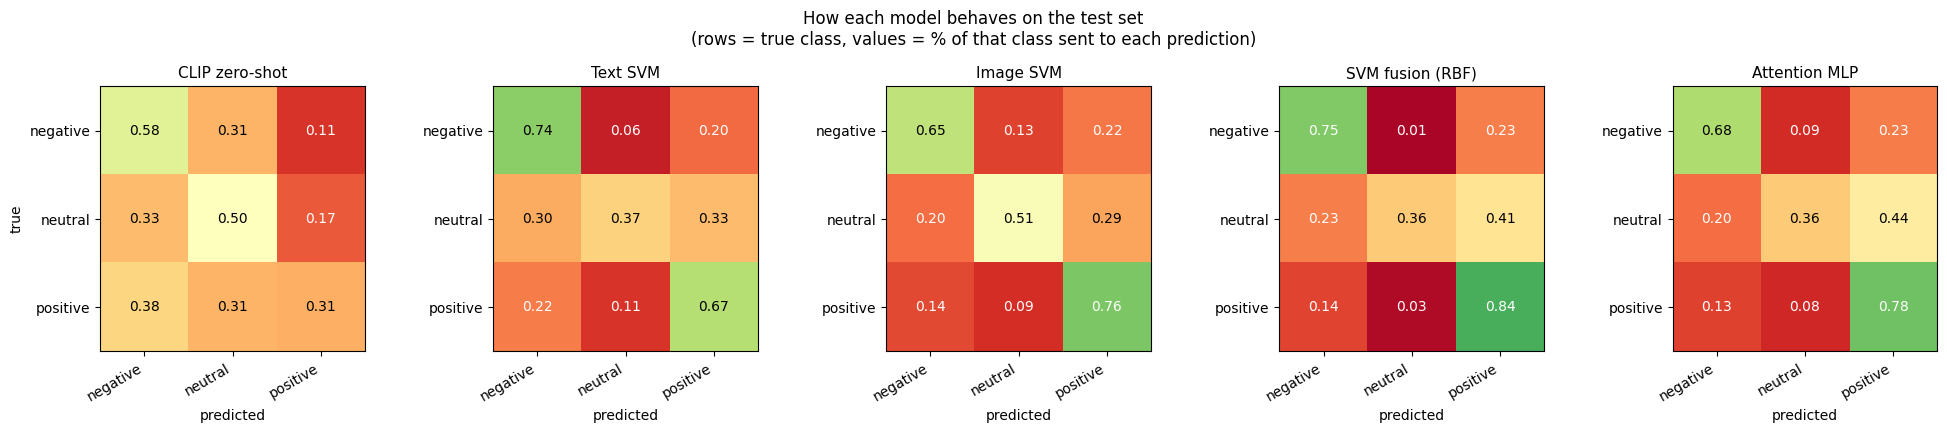

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

CLASSES = ['negative', 'neutral', 'positive']

models = {
    'CLIP zero-shot':   clip_zs,
    'Text SVM':         text_preds,
    'Image SVM':        img_preds,
    'SVM fusion (RBF)': svm_fus,
    'Attention MLP':    mlp_attn,
}

fig, axes = plt.subplots(1, len(models), figsize=(4 * len(models), 4))

for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(test_lab, preds, labels=CLASSES, normalize='true')
    im = ax.imshow(cm, cmap='RdYlGn', vmin=0, vmax=1, aspect='equal')
    ax.set_title(name, fontsize=11)
    ax.set_xticks(range(3)); ax.set_xticklabels(CLASSES, rotation=30, ha='right')
    ax.set_yticks(range(3)); ax.set_yticklabels(CLASSES)
    ax.set_xlabel('predicted'); ax.set_ylabel('true' if ax is axes[0] else '')
    for i in range(3):
        for j in range(3):
            val = cm[i, j]
            ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                    fontsize=10, color='black' if 0.25 < val < 0.75 else 'white')

fig.suptitle('How each model behaves on the test set\n(rows = true class, values = % of that class sent to each prediction)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('confusion_grid.png', dpi=200, bbox_inches='tight')
plt.show()

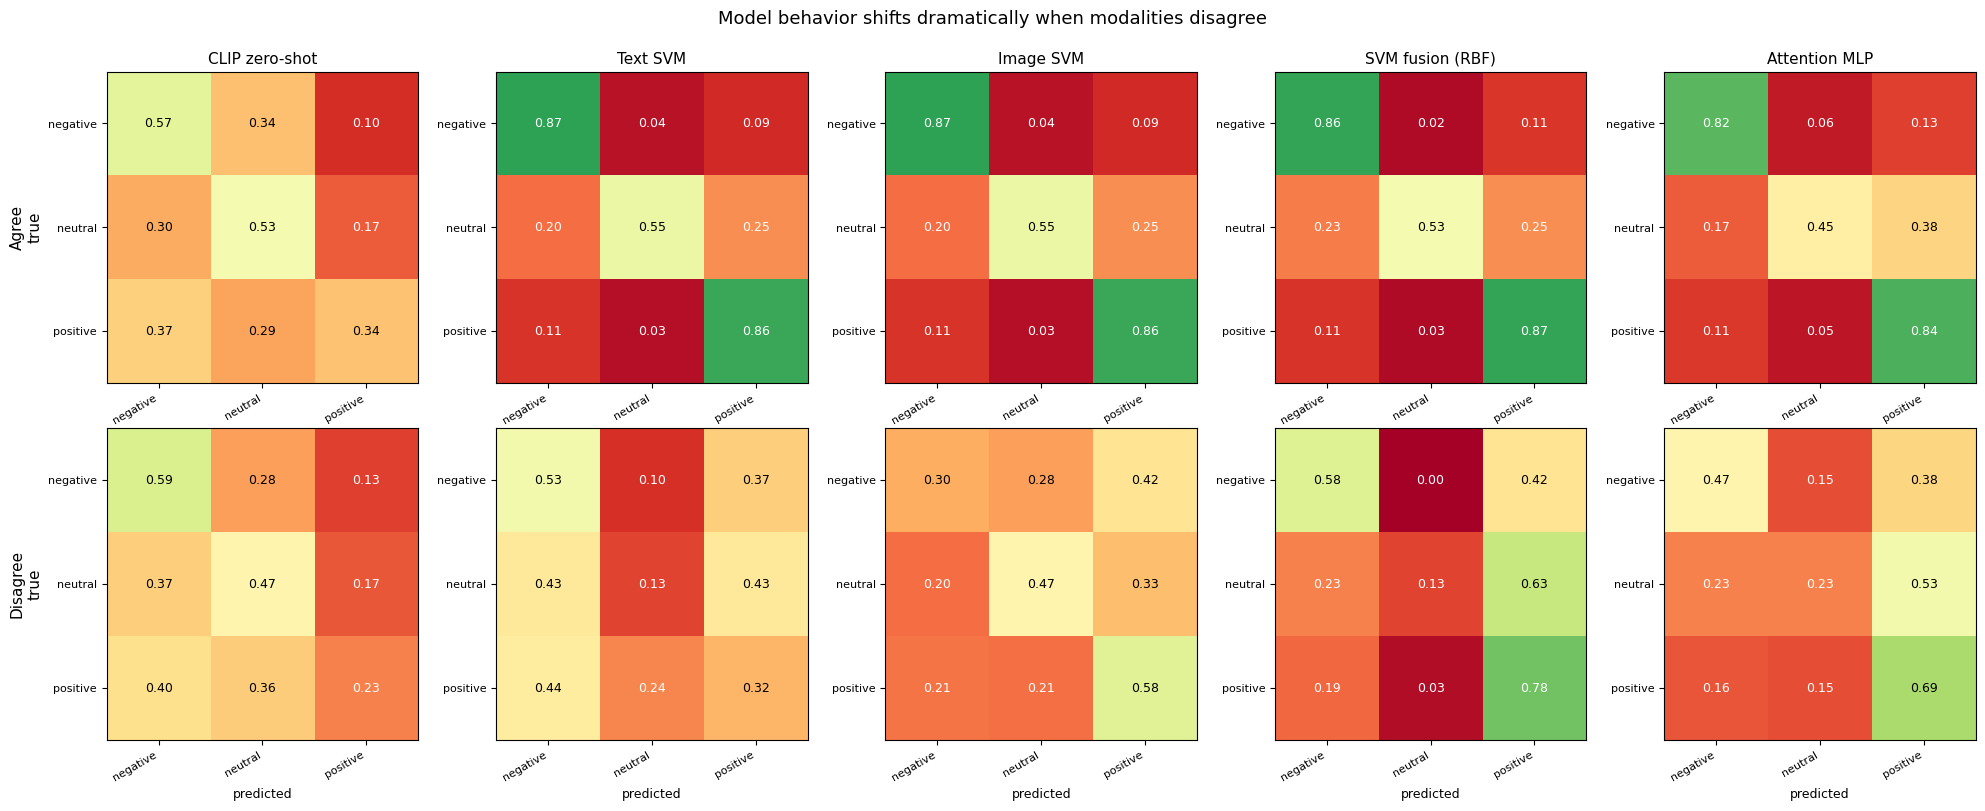

In [ ]:
# Two-row version
fig, axes = plt.subplots(2, len(models), figsize=(4 * len(models), 8))

for col, (name, preds) in enumerate(models.items()):
    for row, (subset_name, mask) in enumerate([('Agree', agree), ('Disagree', disagree)]):
        ax = axes[row, col]
        cm = confusion_matrix(test_lab[mask], preds[mask],
                              labels=CLASSES, normalize='true')
        ax.imshow(cm, cmap='RdYlGn', vmin=0, vmax=1)
        if row == 0: ax.set_title(name, fontsize=11)
        if col == 0: ax.set_ylabel(f'{subset_name}\ntrue', fontsize=11)
        ax.set_xticks(range(3)); ax.set_xticklabels(CLASSES, rotation=30, ha='right', fontsize=8)
        ax.set_yticks(range(3)); ax.set_yticklabels(CLASSES, fontsize=8)
        if row == 1: ax.set_xlabel('predicted', fontsize=9)
        for i in range(3):
            for j in range(3):
                val = cm[i, j]
                ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                        fontsize=9, color='black' if 0.25 < val < 0.75 else 'white')

fig.suptitle('Model behavior shifts dramatically when modalities disagree',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig('confusion_grid_partitioned.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from PIL import Image
from pathlib import Path
import textwrap

EMB_DIR = Path("data/processed/embeddings")
SPLITS_DIR = Path("data/processed/splits")

# === Load test set with image paths and text ===
test_df = pd.read_csv(SPLITS_DIR / "test.csv").reset_index(drop=True)

# === Load all model predictions (saved earlier) ===
preds = {
    'CLIP zero-shot':   np.load(EMB_DIR / "test_pred_clip_zeroshot.npy", allow_pickle=True),
    'Text SVM':         np.load(EMB_DIR / "test_pred_text_svm.npy",      allow_pickle=True),
    'Image SVM':        np.load(EMB_DIR / "test_pred_img_svm.npy",       allow_pickle=True),
    'SVM fusion':       np.load(EMB_DIR / "test_pred_svm_fusion.npy",    allow_pickle=True),
    'Attention MLP':    np.load(EMB_DIR / "test_pred_attn_mlp.npy",      allow_pickle=True),
}
attn = np.load(EMB_DIR / "test_attn_weights.npy")  # (N, 2): [text, img]
y_true = test_df['label'].values

# === Score each test case for "interestingness" ===
n = len(test_df)
correct = {m: (preds[m] == y_true) for m in preds}

# Build a tagged pool of candidate cases
def find_cases():
    cases = []

    # Type A: MLP right, SVM fusion wrong, text-heavy attention (sarcasm winner)
    mask = correct['Attention MLP'] & ~correct['SVM fusion'] & (attn[:, 0] > 0.6)
    for i in np.where(mask)[0]:
        cases.append(('Text-driven save', i))

    # Type B: MLP right, SVM fusion wrong, image-heavy attention (visual winner)
    mask = correct['Attention MLP'] & ~correct['SVM fusion'] & (attn[:, 1] > 0.6)
    for i in np.where(mask)[0]:
        cases.append(('Image-driven save', i))

    # Type C: Unimodal SVMs disagree, MLP correct (multimodal payoff)
    mask = (preds['Text SVM'] != preds['Image SVM']) & correct['Attention MLP']
    for i in np.where(mask)[0]:
        cases.append(('Modality conflict resolved', i))

    # Type D: All models correct (easy / control)
    mask = np.all([correct[m] for m in preds], axis=0)
    for i in np.where(mask)[0]:
        cases.append(('Unanimous agreement', i))

    # Type E: All models wrong (humility / failure mode)
    mask = np.all([~correct[m] for m in preds], axis=0)
    for i in np.where(mask)[0]:
        cases.append(('Universal failure', i))

    return cases

pool = find_cases()
print(f"Candidate cases by type:")
for tag in ['Text-driven save', 'Image-driven save', 'Modality conflict resolved',
            'Unanimous agreement', 'Universal failure']:
    n_tag = sum(1 for t, _ in pool if t == tag)
    print(f"  {tag}: {n_tag}")

Candidate cases by type:
  Text-driven save: 8
  Image-driven save: 19
  Modality conflict resolved: 141
  Unanimous agreement: 142
  Universal failure: 56


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from PIL import Image
from pathlib import Path
import textwrap

EMB_DIR = Path("data/processed/embeddings")
SPLITS_DIR = Path("data/processed/splits")

# === Reload (in case kernel restarted) ===
test_df = pd.read_csv(SPLITS_DIR / "test.csv").reset_index(drop=True)
preds = {
    'CLIP zero-shot': np.load(EMB_DIR / "test_pred_clip_zeroshot.npy", allow_pickle=True),
    'Text SVM':       np.load(EMB_DIR / "test_pred_text_svm.npy",      allow_pickle=True),
    'Image SVM':      np.load(EMB_DIR / "test_pred_img_svm.npy",       allow_pickle=True),
    'SVM fusion':     np.load(EMB_DIR / "test_pred_svm_fusion.npy",    allow_pickle=True),
    'Attention MLP':  np.load(EMB_DIR / "test_pred_attn_mlp.npy",      allow_pickle=True),
}
attn = np.load(EMB_DIR / "test_attn_weights.npy")
y_true = test_df['label'].values
correct = {m: (preds[m] == y_true) for m in preds}

# === Define 10 case types in priority order ===
# Order matters: a case is assigned to the first matching type, so put the
# most specific types first.

case_types = [
    # Group: SAVE (multimodal fusion creates value)
    {
        'tag': 'Text-driven save',
        'group': 'save',
        'desc': 'MLP correct, SVM fusion wrong, attention on text',
        'mask': correct['Attention MLP'] & ~correct['SVM fusion'] & (attn[:, 0] > 0.6),
    },
    {
        'tag': 'Image-driven save',
        'group': 'save',
        'desc': 'MLP correct, SVM fusion wrong, attention on image',
        'mask': correct['Attention MLP'] & ~correct['SVM fusion'] & (attn[:, 1] > 0.6),
    },
    {
        'tag': 'Modality conflict resolved',
        'group': 'save',
        'desc': 'Unimodal SVMs disagree, MLP picks correctly',
        'mask': (preds['Text SVM'] != preds['Image SVM']) & correct['Attention MLP'],
    },
    {
        'tag': 'Fusion creates new signal',
        'group': 'save',
        'desc': 'Both unimodal SVMs wrong, fusion model recovers',
        'mask': (~correct['Text SVM'] & ~correct['Image SVM']
                 & (correct['SVM fusion'] | correct['Attention MLP'])),
    },

    # Group: HARM (multimodal fusion hurts)
    {
        'tag': 'SVM fusion breaks signal',
        'group': 'harm',
        'desc': 'Both unimodal SVMs correct, concatenated SVM wrong',
        'mask': correct['Text SVM'] & correct['Image SVM'] & ~correct['SVM fusion'],
    },
    {
        'tag': 'MLP overrides correct SVM',
        'group': 'harm',
        'desc': 'SVM fusion correct, attention MLP wrong',
        'mask': correct['SVM fusion'] & ~correct['Attention MLP'],
    },

    # Group: PATTERN (interesting model behaviors)
    {
        'tag': 'Zero-shot beats trained',
        'group': 'pattern',
        'desc': 'CLIP zero-shot correct, all trained models wrong',
        'mask': (correct['CLIP zero-shot'] & ~correct['Text SVM']
                 & ~correct['Image SVM'] & ~correct['SVM fusion']
                 & ~correct['Attention MLP']),
    },
    {
        'tag': 'Neutral collapse',
        'group': 'pattern',
        'desc': 'True label is neutral, MLP sends it elsewhere',
        'mask': (y_true == 'neutral') & ~correct['Attention MLP'],
    },

    # Group: BASELINE (control cases)
    {
        'tag': 'Unanimous agreement',
        'group': 'baseline',
        'desc': 'All five models predict the true label',
        'mask': np.all([correct[m] for m in preds], axis=0),
    },
    {
        'tag': 'Universal failure',
        'group': 'baseline',
        'desc': 'All five models miss the true label',
        'mask': np.all([~correct[m] for m in preds], axis=0),
    },
]

# === Print candidate counts ===
print(f"{'Type':<32} {'Group':<10} {'Count':<6}")
print("-" * 50)
for ct in case_types:
    print(f"{ct['tag']:<32} {ct['group']:<10} {ct['mask'].sum():<6}")

Type                             Group      Count 
--------------------------------------------------
Text-driven save                 save       8     
Image-driven save                save       19    
Modality conflict resolved       save       141   
Fusion creates new signal        save       24    
SVM fusion breaks signal         harm       4     
MLP overrides correct SVM        harm       70    
Zero-shot beats trained          pattern    30    
Neutral collapse                 pattern    45    
Unanimous agreement              baseline   142   
Universal failure                baseline   56    


In [ ]:
PER_TYPE = 2   # change to 1 for a smaller gallery, 3 for a bigger one
np.random.seed(42)

selected = []
used = set()

for ct in case_types:
    candidates = [int(i) for i in np.where(ct['mask'])[0] if int(i) not in used]
    if not candidates:
        continue
    # Prefer non-empty, reasonable-length text
    candidates = [i for i in candidates if 20 < len(test_df.iloc[i]['text']) < 200] or candidates
    pick_n = min(PER_TYPE, len(candidates))
    picks = np.random.choice(candidates, size=pick_n, replace=False)
    for idx in picks:
        selected.append({**ct, 'idx': int(idx)})
        used.add(int(idx))

print(f"\nSelected {len(selected)} cases across {len(set(s['tag'] for s in selected))} types")
for s in selected:
    print(f"  [{s['idx']:4d}] {s['tag']:<32} true={y_true[s['idx']]:<8} "
          f"text='{test_df.iloc[s['idx']]['text'][:50]}...'")


Selected 20 cases across 10 types
  [ 254] Text-driven save                 true=negative text='RT @hayleystringss: Heartbreaking moment when you ...'
  [ 494] Text-driven save                 true=positive text='It's foggy out there #eastbourne https://t.co/PHzG...'
  [ 223] Image-driven save                true=positive text='RT @kjo19: Hey Blue Jays Nation......'
  [ 542] Image-driven save                true=positive text='RT @johnnyb199: When you are taken aback by the bo...'
  [ 379] Modality conflict resolved       true=positive text='RT @crashspain: Wonderful Turner Field Tour today....'
  [ 524] Modality conflict resolved       true=negative text='Get and eat the dirt off my walking boots you #inf...'
  [ 146] Fusion creates new signal        true=positive text='#zealous #newyearsday Paidsocialmediajobs. - new #...'
  [ 324] Fusion creates new signal        true=positive text='Camera Deals : Black WiFi 1080P Full HD Helmet Spo...'
  [ 632] SVM fusion breaks signal         tru

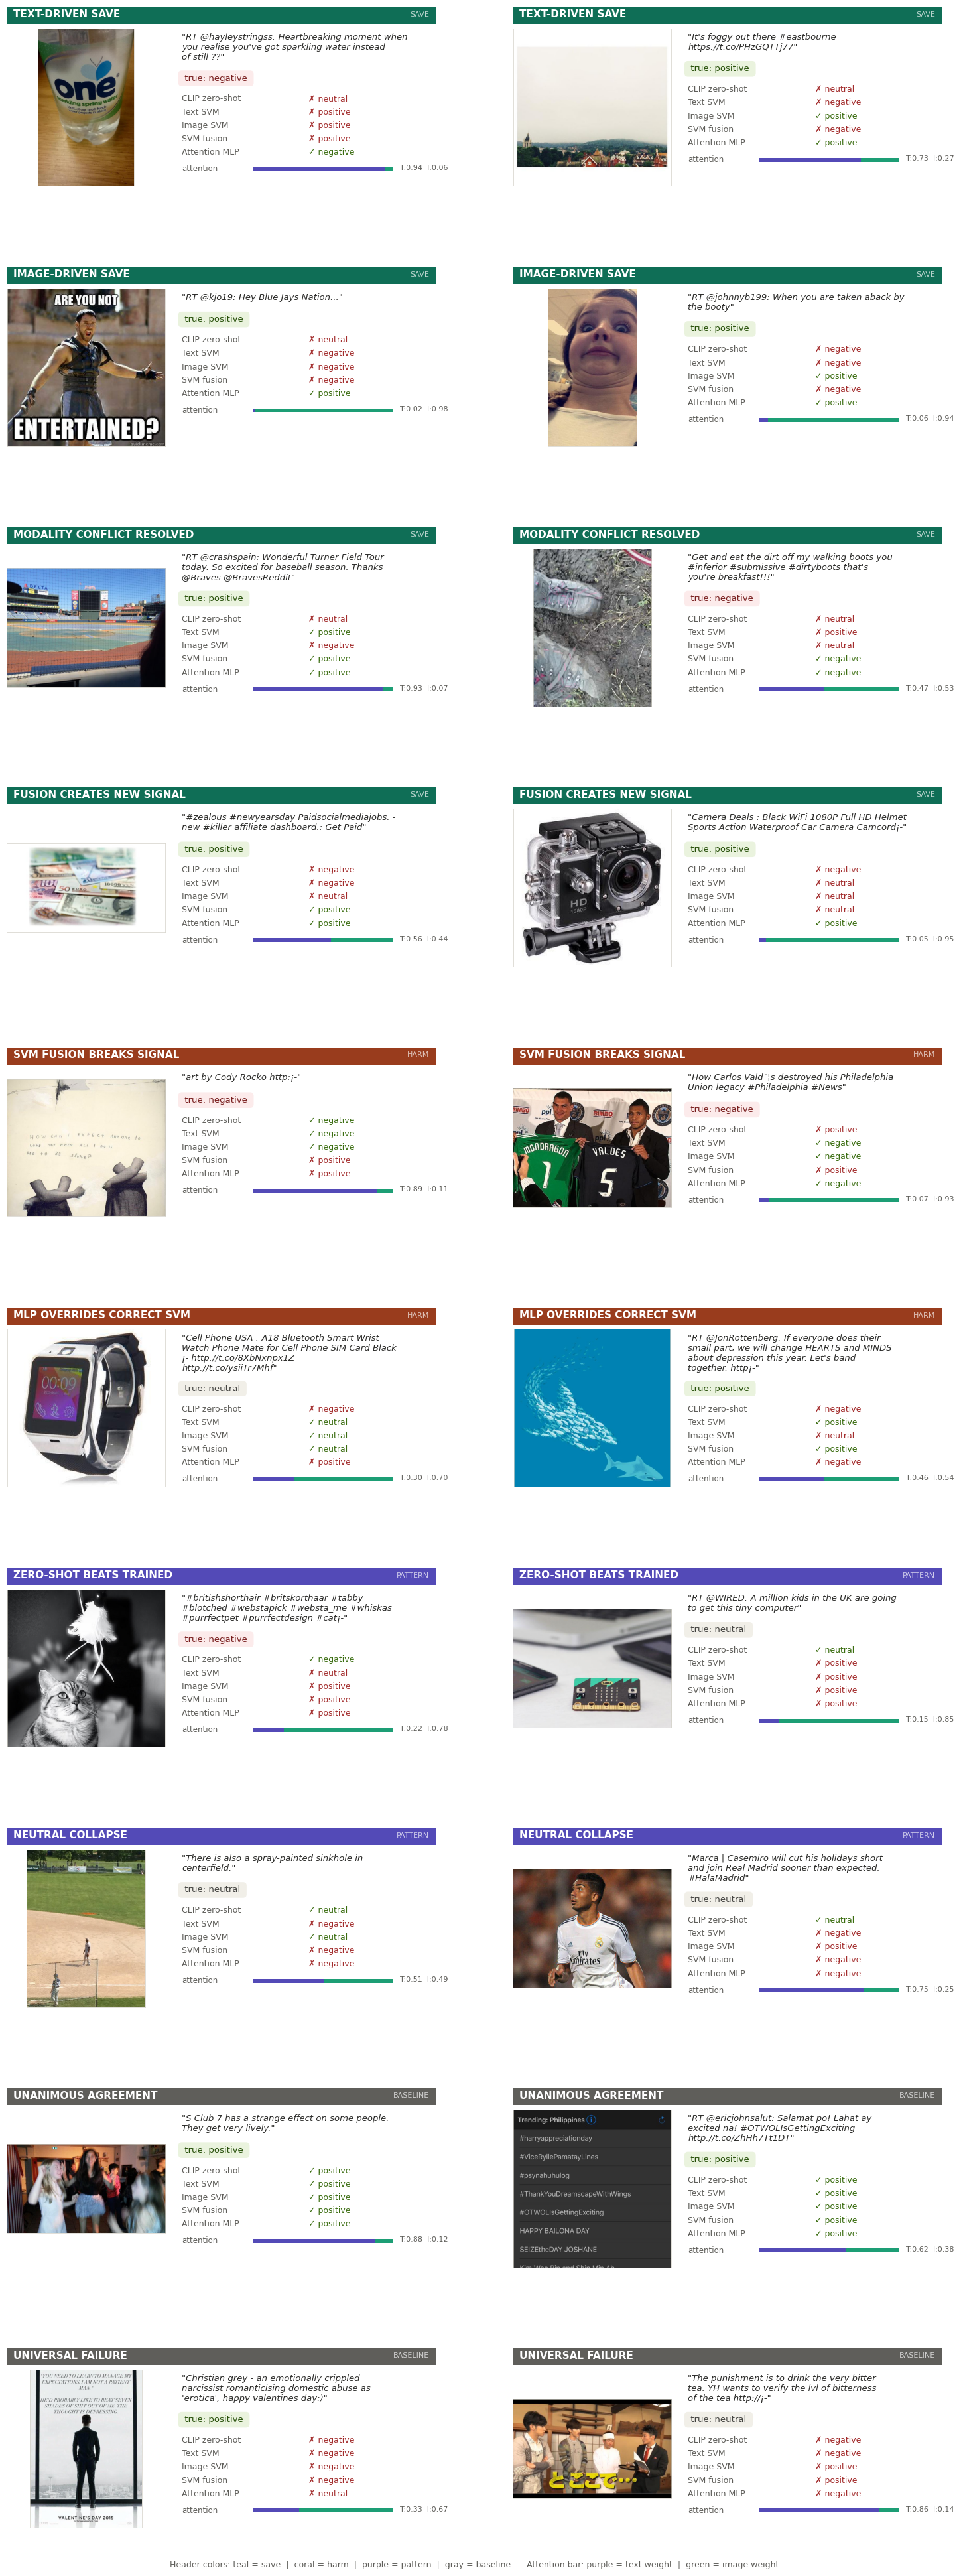

In [ ]:
GROUP_STYLE = {
    'save':     {'bar': '#0F6E56', 'text_on_bar': 'white'},
    'harm':     {'bar': '#993C1D', 'text_on_bar': 'white'},
    'pattern':  {'bar': '#534AB7', 'text_on_bar': 'white'},
    'baseline': {'bar': '#5F5E5A', 'text_on_bar': 'white'},
}
LABEL_FG = {'positive': '#27500A', 'negative': '#791F1F', 'neutral': '#444441'}
LABEL_BG = {'positive': '#EAF3DE', 'negative': '#FCEBEB', 'neutral': '#F1EFE8'}

n_cases = len(selected)
n_cols = 2
n_rows = (n_cases + n_cols - 1) // n_cols
CARD_H = 4.0  # inches per row

fig = plt.figure(figsize=(15, CARD_H * n_rows))
outer = GridSpec(n_rows, n_cols, figure=fig, hspace=0.45, wspace=0.18,
                 left=0.03, right=0.97, top=0.97, bottom=0.02)

for slot, case in enumerate(selected):
    row, col = slot // n_cols, slot % n_cols
    style = GROUP_STYLE[case['group']]
    idx = case['idx']

    # Card = vertical stack: header bar (15%) + content (85%)
    card = outer[row, col].subgridspec(2, 1, height_ratios=[0.6, 5.5], hspace=0.05)

    # === Header bar with tag ===
    ax_header = fig.add_subplot(card[0])
    ax_header.set_xlim(0, 1); ax_header.set_ylim(0, 1)
    ax_header.axis('off')
    ax_header.add_patch(mpatches.Rectangle(
        (0, 0), 1, 1, facecolor=style['bar'], transform=ax_header.transAxes))
    ax_header.text(0.015, 0.55, case['tag'].upper(),
                   color=style['text_on_bar'], fontsize=11, fontweight='bold',
                   va='center', ha='left', transform=ax_header.transAxes)
    ax_header.text(0.985, 0.55, case['group'].upper(),
                   color=style['text_on_bar'], fontsize=8, fontweight='500',
                   va='center', ha='right', alpha=0.7,
                   transform=ax_header.transAxes)

    # === Content row: image | text ===
    content = card[1].subgridspec(1, 2, width_ratios=[1, 1.6], wspace=0.08)

    # Image
    ax_img = fig.add_subplot(content[0])
    try:
        img = Image.open(test_df.iloc[idx]['image_path']).convert("RGB")
        ax_img.imshow(img)
    except Exception:
        ax_img.text(0.5, 0.5, '[image error]', ha='center', va='center',
                    transform=ax_img.transAxes)
    ax_img.set_xticks([]); ax_img.set_yticks([])
    for s in ax_img.spines.values():
        s.set_edgecolor('#D3D1C7'); s.set_linewidth(0.5)

    # Text + predictions
    ax_txt = fig.add_subplot(content[1])
    ax_txt.set_xlim(0, 1); ax_txt.set_ylim(0, 1)
    ax_txt.axis('off')

    text = test_df.iloc[idx]['text']
    wrapped = textwrap.fill(text, width=46)
    if wrapped.count('\n') > 3:
        wrapped = '\n'.join(wrapped.split('\n')[:3]) + ' ...'

    y = 0.97
    ax_txt.text(0.0, y, f'"{wrapped}"', fontsize=9.5, va='top', ha='left',
                style='italic', color='#2C2C2A',
                transform=ax_txt.transAxes)
    y -= 0.08 + 0.06 * (wrapped.count('\n') + 1)

    # True label badge
    true_lab = y_true[idx]
    ax_txt.text(0.0, y, f' true: {true_lab} ', fontsize=9.5,
                color=LABEL_FG[true_lab], fontweight='500',
                bbox=dict(boxstyle='round,pad=0.4',
                          facecolor=LABEL_BG[true_lab], edgecolor='none'),
                transform=ax_txt.transAxes, va='top')
    y -= 0.13

    # Model predictions table
    for model_name in preds:
        pred = preds[model_name][idx]
        is_correct = (pred == true_lab)
        mark, color = ('✓', '#3B6D11') if is_correct else ('✗', '#A32D2D')
        ax_txt.text(0.0, y, model_name, fontsize=9, color='#5F5E5A',
                    transform=ax_txt.transAxes, va='top')
        ax_txt.text(0.50, y, f'{mark} {pred}', fontsize=9, color=color,
                    transform=ax_txt.transAxes, va='top', fontweight='500')
        y -= 0.085

    # Attention bar (only meaningful when MLP gating exists)
    y -= 0.02
    text_w, img_w = float(attn[idx, 0]), float(attn[idx, 1])
    ax_txt.text(0.0, y, 'attention', fontsize=8.5, color='#5F5E5A',
                transform=ax_txt.transAxes, va='top')
    bar_y = y - 0.04
    ax_txt.add_patch(mpatches.Rectangle(
        (0.28, bar_y), 0.55 * text_w, 0.025,
        facecolor='#534AB7', transform=ax_txt.transAxes, clip_on=False))
    ax_txt.add_patch(mpatches.Rectangle(
        (0.28 + 0.55 * text_w, bar_y), 0.55 * img_w, 0.025,
        facecolor='#1D9E75', transform=ax_txt.transAxes, clip_on=False))
    ax_txt.text(0.86, y, f'T:{text_w:.2f}  I:{img_w:.2f}', fontsize=8,
                color='#5F5E5A', transform=ax_txt.transAxes, va='top')

# Bottom legend
legend_y = 0.005
fig.text(0.5, legend_y,
         'Header colors: teal = save  |  coral = harm  |  purple = pattern  |  gray = baseline      '
         'Attention bar: purple = text weight  |  green = image weight',
         ha='center', fontsize=9, color='#5F5E5A')

plt.savefig('case_gallery_extended.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
# === Pick one of each type for a balanced gallery ===
np.random.seed(42)

def pick_one(pool, tag, used):
    candidates = [i for t, i in pool if t == tag and i not in used]
    if not candidates:
        return None
    return np.random.choice(candidates)

selected = []
used = set()
for tag in ['Text-driven save', 'Image-driven save', 'Modality conflict resolved',
            'Unanimous agreement', 'Universal failure']:
    idx = pick_one(pool, tag, used)
    if idx is not None:
        selected.append((tag, int(idx)))
        used.add(int(idx))

# Pad to 6 cases if we got fewer
while len(selected) < 6:
    extra = pick_one(pool, 'Modality conflict resolved', used)
    if extra is None: break
    selected.append(('Modality conflict resolved', int(extra)))
    used.add(int(extra))

print(f"\nSelected {len(selected)} cases:")
for tag, idx in selected:
    print(f"  [{idx}] {tag}: true={y_true[idx]}, text='{test_df.iloc[idx]['text'][:60]}...'")


Selected 6 cases:
  [604] Text-driven save: true=neutral, text='Less than a minute left in the half, #cardinals are up 27-21...'
  [528] Image-driven save: true=positive, text='RT @CruddyTrip: They turned the gas station into a party ???...'
  [523] Modality conflict resolved: true=neutral, text='The cool New Two-Colour Zippy Pencil Case with matching Zipp...'
  [315] Unanimous agreement: true=positive, text='Word for Today: ardent. adjective. having, expressive of, or...'
  [290] Universal failure: true=negative, text='RT @NME: 'Meat Is Murder' turned 30 this week. Here's how it...'
  [499] Modality conflict resolved: true=negative, text='Smiling Iguana Laurentis. #fotomanhef #canon #iguana #lauren...'


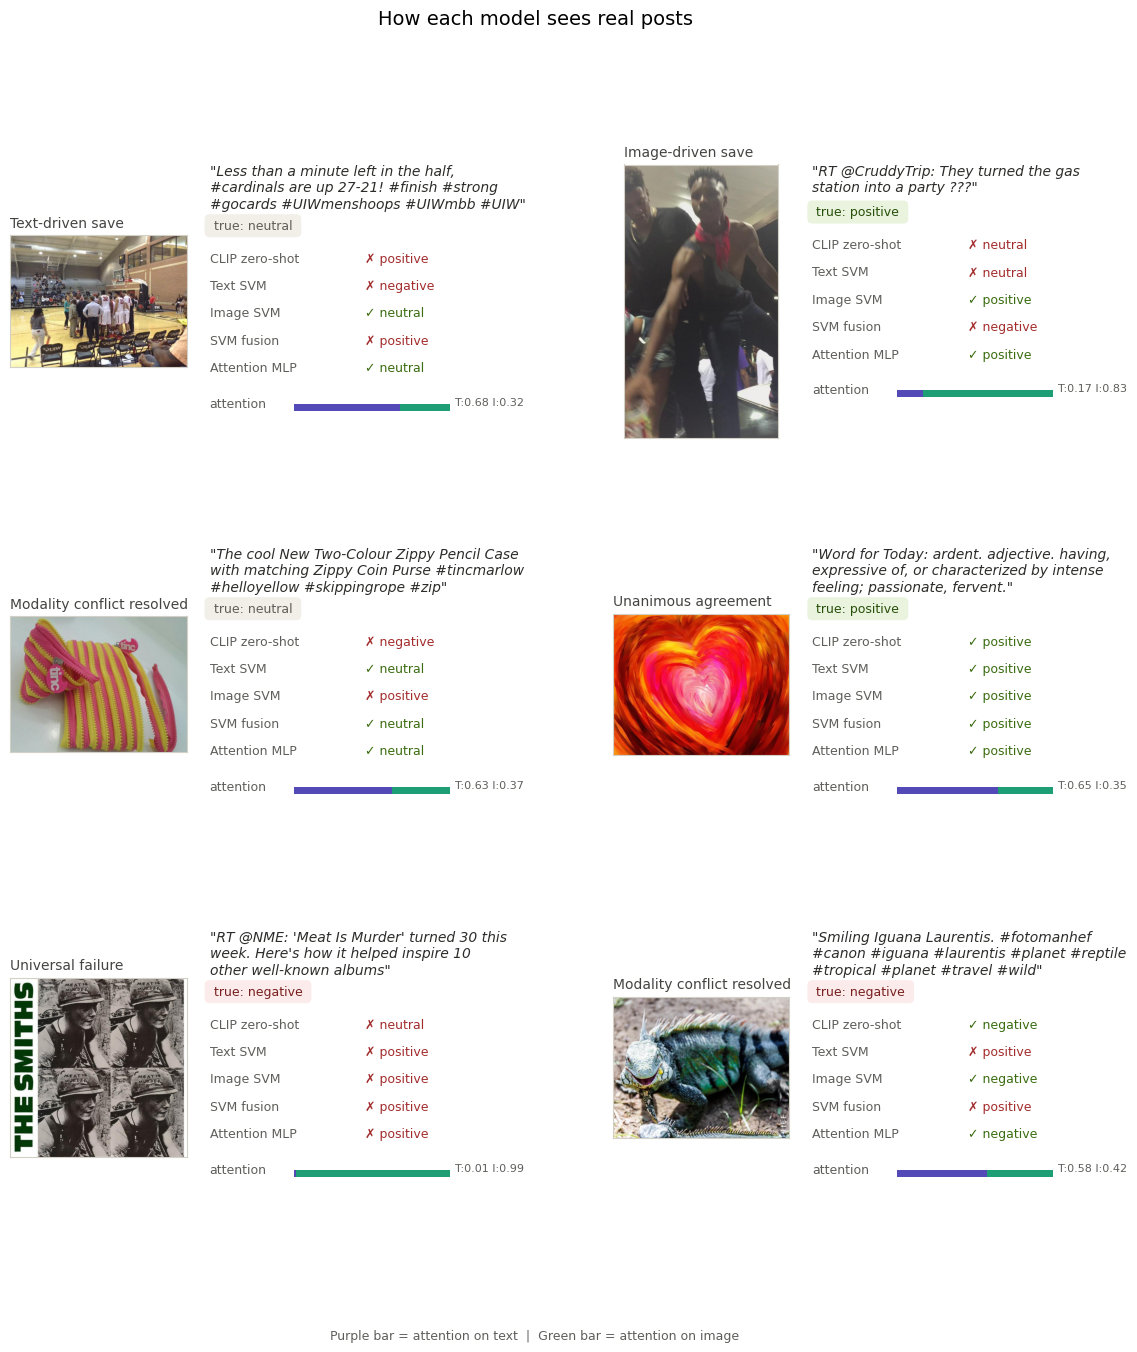

In [ ]:
# === Render the gallery ===
LABEL_COLORS = {'positive': '#27500A', 'negative': '#791F1F', 'neutral': '#5F5E5A'}
LABEL_BG     = {'positive': '#EAF3DE', 'negative': '#FCEBEB', 'neutral': '#F1EFE8'}

n_cases = len(selected)
n_cols = 2
n_rows = (n_cases + 1) // 2

fig = plt.figure(figsize=(14, 4.5 * n_rows))
gs = GridSpec(n_rows, n_cols, figure=fig, hspace=0.4, wspace=0.25)

for slot, (tag, idx) in enumerate(selected):
    row, col = slot // n_cols, slot % n_cols
    inner = gs[row, col].subgridspec(1, 2, width_ratios=[1, 1.6], wspace=0.1)

    # --- Left: image ---
    ax_img = fig.add_subplot(inner[0])
    try:
        img = Image.open(test_df.iloc[idx]['image_path']).convert("RGB")
        ax_img.imshow(img)
    except Exception as e:
        ax_img.text(0.5, 0.5, f"[image error]", ha='center', va='center')
    ax_img.set_xticks([]); ax_img.set_yticks([])
    for spine in ax_img.spines.values():
        spine.set_edgecolor('#D3D1C7'); spine.set_linewidth(0.8)

    # Tag badge above image
    ax_img.set_title(tag, fontsize=10, color='#444441',
                     loc='left', pad=6, fontweight='500')

    # --- Right: text + predictions ---
    ax_txt = fig.add_subplot(inner[1])
    ax_txt.axis('off')

    text = test_df.iloc[idx]['text']
    wrapped = textwrap.fill(text, width=42)
    if len(wrapped) > 200:
        wrapped = wrapped[:200] + "..."

    true_lab = y_true[idx]
    y = 1.0

    # Tweet text
    ax_txt.text(0, y, f'"{wrapped}"', fontsize=10, va='top', ha='left',
                style='italic', color='#2C2C2A',
                transform=ax_txt.transAxes, wrap=True)
    y -= 0.05 + 0.05 * (wrapped.count('\n') + 1)

    # True label badge
    ax_txt.text(0, y, f' true: {true_lab} ', fontsize=9,
                color=LABEL_COLORS[true_lab],
                bbox=dict(boxstyle='round,pad=0.4', facecolor=LABEL_BG[true_lab],
                          edgecolor='none'),
                transform=ax_txt.transAxes, va='top')
    y -= 0.12

    # Model predictions table
    for model_name in preds:
        pred = preds[model_name][idx]
        is_correct = (pred == true_lab)
        mark, color = ('✓', '#3B6D11') if is_correct else ('✗', '#A32D2D')
        ax_txt.text(0.00, y, model_name, fontsize=9, color='#5F5E5A',
                    transform=ax_txt.transAxes, va='top')
        ax_txt.text(0.55, y, f'{mark} {pred}', fontsize=9, color=color,
                    transform=ax_txt.transAxes, va='top', fontweight='500')
        y -= 0.10

    # Attention weight bar
    y -= 0.03
    text_w, img_w = attn[idx, 0], attn[idx, 1]
    ax_txt.text(0.00, y, 'attention', fontsize=9, color='#5F5E5A',
                transform=ax_txt.transAxes, va='top')
    bar_y = y - 0.05
    ax_txt.add_patch(mpatches.Rectangle((0.30, bar_y), 0.55 * text_w, 0.025,
                                         facecolor='#534AB7',
                                         transform=ax_txt.transAxes, clip_on=False))
    ax_txt.add_patch(mpatches.Rectangle((0.30 + 0.55 * text_w, bar_y), 0.55 * img_w, 0.025,
                                         facecolor='#1D9E75',
                                         transform=ax_txt.transAxes, clip_on=False))
    ax_txt.text(0.87, y, f'T:{text_w:.2f} I:{img_w:.2f}', fontsize=8,
                color='#5F5E5A', transform=ax_txt.transAxes, va='top')

# Legend at bottom
fig.text(0.5, 0.01,
         'Purple bar = attention on text  |  Green bar = attention on image',
         ha='center', fontsize=9, color='#5F5E5A')

plt.suptitle('How each model sees real posts', fontsize=14, y=0.995, fontweight='500')
plt.savefig('case_gallery.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()